In [8]:
import pickle
import pandas as pd
name = 'ilp'
graph_type = 'ca'
max_num_nodes = 4000
formulations = ['max_linear_square']
proposal_types = ['penalty_square']
init_temps = [1]
path_lengths = [10]
penalty_weight = 1000000
t_schedule = 'pt'
t_min_list = [0.01,0.02,0.05,0.1,0.2,0.5,1.0,2.0]
t_max_list = [0.1,0.2,0.5,1.0,2.0,5.0]
reweights = ['mask']
batch_size = 50

df = pd.DataFrame(columns = [t_max_list],index=[t_min_list])
for formulation in formulations:
    for init_temp in init_temps:
        for path_length in path_lengths:
            for reweight in reweights:
                # for proposal_type in proposal_types:
                for t_min in t_min_list:
                    for t_max in t_max_list:
                        if t_min >= t_max:
                            continue
                        path = f'./discs/results/{name}/results_{name}_{graph_type}_{max_num_nodes}_{formulation}_{init_temp}_{path_length}_{penalty_weight}_{t_schedule}_deo_1000_{t_min}_{t_max}_{reweight}_{batch_size}.pkl'
                        try:
                            with open(path, 'rb') as f:
                                data1 = pickle.load(f)
                        except:
                            continue
                        df.loc[t_min,t_max] = data1['best_ratio_mean']
                        if len(data1['best_ratio']) <20:
                            df.loc[t_min,t_max] =  len(data1['best_ratio'])
df          
                        # print(f'graph_type: {graph_type}, formulation: {formulation}, proposal_type:, init_temp: {init_temp}, reweight: {reweight}, best_ratio_mean: {data1["best_ratio_mean"]}')

,0.1,0.2,0.5,1.0,2.0,5.0
0.01,92659.328125,92590.367188,92569.171875,92703.28125,92787.640625,94139.578125
0.02,92672.890625,92500.726562,92569.765625,92687.234375,92813.0,94313.40625
0.05,92646.234375,92780.476562,92489.773438,92731.53125,92883.734375,94338.796875
0.10,NaN,92678.59375,92596.1875,92659.898438,92771.953125,9
0.20,NaN,NaN,92584.84375,92728.679688,15,NaN
0.50,NaN,NaN,NaN,NaN,NaN,NaN
1.00,NaN,NaN,NaN,NaN,NaN,NaN
2.00,NaN,NaN,NaN,NaN,NaN,NaN


# 2

In [11]:
import pickle
import pandas as pd
name = 'ilp'
graph_type = 'mis'
max_num_nodes = 1500
formulations = ['max_linear_square']
proposal_types = ['obj']
init_temps = [5,2,1]
path_lengths = [1]
penalty_weight = 1000000000
t_schedule = 'exp_decay'
sampler_name='path_auxiliary'
balancing_fn = 'SQRT'
t_min_list = [0.1]
t_max_list = [5]
reweights = ['mask']
batch_size = 32

for formulation in formulations:
    for init_temp in init_temps:
        for path_length in path_lengths:
            for reweight in reweights:
                for proposal_type in proposal_types:
                
                    path = f'./discs/results/{name}/results_{name}_{graph_type}_{max_num_nodes}_{sampler_name}_{balancing_fn}_{formulation}_{proposal_type}_{init_temp}_{path_length}_{penalty_weight}_{t_schedule}_deo_1000_0.1_5.0_{reweight}_{batch_size}.pkl'
                    # print(path)
                    with open(path, 'rb') as f:
                        data1 = pickle.load(f)
                    if len(data1['best_ratio']) <100:
                        print(len(data1['best_ratio']))
                    else:
                        print(f'graph_type: {graph_type}, formulation: {formulation}, proposal_type:, init_temp: {init_temp}, reweight: {reweight}, best_ratio_mean: {data1["best_ratio_mean"]}')

42


FileNotFoundError: [Errno 2] No such file or directory: './discs/results/ilp/results_ilp_mis_1500_path_auxiliary_SQRT_max_linear_square_obj_2_1_1000000000_exp_decay_deo_1000_0.1_5.0_mask_32.pkl'

In [12]:
data1['best_ratio']

array([-1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09,
       -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09,
       -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09,
       -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09,
       -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09,
       -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09, -1.e+09],
      dtype=float32)

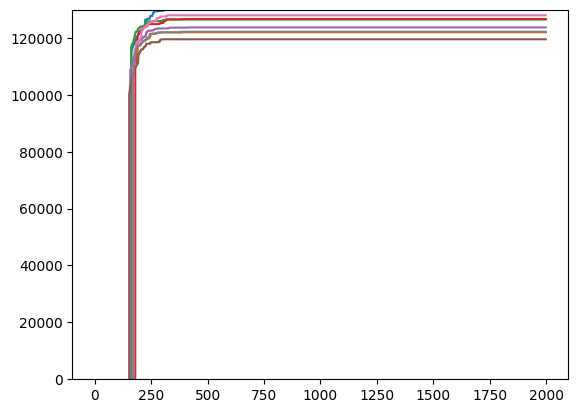

In [29]:
import matplotlib.pyplot as plt
for i in range(len(data1['best_ratio'])):
    plt.plot(data1['trajectory'][:,i])
    plt.ylim(-100,130000)